# 3.6 Régression logistique

_Attention !_ Malgré son nom de _régression_ logistique, la régression logistique est en réalité une méthode de _classification_.

Par Ariane Ducellier (2021)

🖥️ [**Diapositives du cours — Séance 16 (mer. 4 nov.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec16_honest_probabilities.html)

Dans ce TP, nous allons parler :
- d'une méthode de classification simple : la régression logistique ;
- de la méthode de descente de gradient ;
- de la différenciation automatique ;
- d'une introduction à PyTorch.

## Régression logistique

Rappelons la régression linéaire :

$y = b + x w + \epsilon$

$y$ est un vecteur de longueur $n$, $x$ est une matrice à $n$ lignes et $p$ colonnes, correspondant à $n$ observations et $p$ caractéristiques utilisées pour expliquer $y$.

$b$ est un scalaire. $w$ est un vecteur de longueur $p$. $\epsilon$ est un vecteur d'erreur aléatoire, de longueur $n$. Il est indépendant de $x$ et de moyenne nulle.

Notre objectif est de trouver les meilleures valeurs de $b$ et $w$ pour que les valeurs de $\hat{y} = b + x w$ soient aussi proches que possible des valeurs réelles $y$.

Pour la régression linéaire, $y$ est une variable quantitative. Que faire si $y$ est une variable qualitative, par exemple $y = 0$ pour « non » et $y = 1$ pour « oui » ?

Une façon d'utiliser la régression pour résoudre un problème de classification est de modéliser la probabilité que la variable $y$ prenne la valeur 1 :

$P (y = 1) = b + x w$

Une fois trouvées les meilleures valeurs $\hat{b}$ et $\hat{w}$, nous calculons $\hat{y} = \hat{b} + x \hat{w}$. Si $\hat{y} \geq 0.5$, nous décidons de classer cette observation comme $y = 1$, c'est-à-dire « oui ». Si $\hat{y} < 0.5$, nous décidons de classer cette observation comme $y = 0$, c'est-à-dire « non ».

Cette méthode pose un problème. Nous voudrions avoir $0 \leq P (y = 1) \leq 1$ puisqu'il s'agit d'une probabilité. Or rien dans cette formulation ne force $b$ et $w$ à prendre des valeurs telles que $\hat{y} = \hat{b} + x \hat{w}$ reste toujours dans $[0, 1]$.

Pour résoudre ce problème, nous pouvons écrire à la place :

$z = b + x w$ et $P (y = 1) = \frac{1}{1 + e^{-z}}$

Ainsi, nous avons toujours $0 \leq P (y = 1) \leq 1$. Quand $b + x w$ devient grand, $P (y = 1)$ s'approche de 1, et la valeur « oui » devient de plus en plus probable. Quand $b + x w$ devient petit, $P (y = 1)$ s'approche de 0, et la valeur « non » devient de plus en plus probable.

Comment trouver la valeur optimale de $b$ et $w$ ? Nous définissons la fonction de perte d'entropie croisée. Pour une observation, la fonction de perte s'écrit :

$\mathcal{L} = - (y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i)$ avec $\hat{y}_i = \frac{1}{1 + e^{- (b + x_i^T w)}}$ où $x_i$ est la $i$-ième ligne de x.

Si l'observation vraie $y_i$ vaut 1 (« oui ») et que $\hat{y}_i = 1$, la fonction de perte vaut 0. Si $\hat{y}_i = 0$, la fonction de perte tend vers l'infini.

Si l'observation vraie $y$ vaut 0 (« non ») et que $\hat{y}_i = 0$, la fonction de perte vaut 0. Si $\hat{y}_i = 1$, la fonction de perte tend vers l'infini.

Pour l'ensemble des $n$ observations, nous écrivons :

$\mathcal{L} = \sum_{i = 1}^n \mathcal{L}_i$

Notre objectif est donc de trouver les valeurs de $b$ et $\omega$ qui minimisent la fonction de perte. Notez qu'avec cette formulation, $\mathcal{L}$ est toujours positive.

## Descente de gradient

Nous savons que le gradient $\frac{\partial \mathcal{L}}{\partial w_j}$ est positif si la perte $\mathcal{L}$ augmente quand $w_j$ augmente. Inversement, le gradient $\frac{\partial \mathcal{L}}{\partial w_j}$ est négatif si la perte $\mathcal{L}$ diminue quand $w_j$ augmente.

Pour obtenir des valeurs de plus en plus petites de la perte, à chaque itération nous prenons :

$w_j^{(k + 1)} = w_j^{(k)} - \alpha \frac{\partial \mathcal{L}}{\partial w_j}$ pour $j = 1 , \cdots , p$

$b^{(k + 1)} = b^{(k)} - \alpha \frac{\partial \mathcal{L}}{\partial b}$

Nous supposons que la valeur de $\alpha$ n'est pas trop grande. Si le gradient est positif, la valeur de $w_j$ diminuera à chaque itération, et la valeur de la fonction de perte diminuera. Si le gradient est négatif, la valeur de $w_j$ augmentera à chaque itération, et la valeur de la perte diminuera.

Il ne nous reste donc plus qu'à calculer le gradient de la fonction de perte.

## Différenciation automatique

Il existe trois façons de calculer le gradient. La première méthode consiste à partir de la formule de la perte :

$\mathcal{L} (w_j , b) = - \sum_{i = 1}^n y_i \log (\frac{1}{1 + \exp (- b - \sum_{j = 1}^p w_j x_{i,j})}) + (1 - y_i) \log (1 - \frac{1}{1 + \exp (- b - \sum_{j = 1}^p w_j x_{i,j})})$

et à calculer la formule exacte des dérivées $\frac{\partial \mathcal{L}}{\partial w_j}$ et $\frac{\partial \mathcal{L}}{\partial b}$. Il ne reste alors qu'à implémenter la formule exacte dans le code pour calculer le gradient.

Quand la formule se complique de plus en plus, vous devenez de plus en plus susceptible de commettre une erreur, soit dans le calcul de la formule de la dérivée, soit dans son implémentation dans votre code.

La deuxième méthode consiste à calculer une approximation du gradient :

$\frac{\partial \mathcal{L}}{\partial w_j} = \frac{\mathcal{L}(w_j + \Delta w_j) - \mathcal{L}(w_j)}{\Delta W_j}$

Si vous accumulez trop d'approximations, la méthode peut mal fonctionner et donner des résultats inexacts.

La troisième méthode est la différenciation automatique. Si nous écrivons :

$z = x_i^T w + b = f_x(w, b)$, $\sigma = \frac{1}{1 + e^{-z}} = g(z)$ et $L = - (y_i \log(\sigma) + (1 - y_i) \log(1 - \sigma)) = h_y(\sigma)$, nous obtenons :

$\frac{\partial L}{\partial w_j} = \frac{\partial f}{\partial w_j} g'(z) h'(\sigma)$

Il est très facile de calculer la formule exacte des dérivées :

$\frac{\partial f}{\partial w_j}(w, b) = x_{i,j}$

$g'(z) = \frac{e^{-z}}{(1 + e^{-z})^2}$

$h'(\sigma) = - \frac{y_i}{\sigma} + \frac{1 - y_i}{1 - \sigma}$

Lors du calcul de $L$, nous devons donc garder en mémoire les valeurs de $\frac{\partial f}{\partial w_j}(w, b)$, $g'(z)$ et $h'(\sigma)$ pour pouvoir calculer le gradient. C'est ce que fait PyTorch.

## Introduction à PyTorch

PyTorch (https://pytorch.org/) est un paquet Python qui permet de construire et d'entraîner des réseaux de neurones. Il repose sur la différenciation automatique.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Les données : potabilité de l'eau

Nous utilisons une table de mesures de qualité de l'eau avec une cible binaire, `Potability` (0 = non potable, 1 = potable). Chaque ligne compte 9 caractéristiques numériques (pH, dureté, solides dissous, etc.).

```{admonition} Provenance des données
:class: warning
Cette table a circulé sur Kaggle (https://www.kaggle.com/adityakadiwal/water-potability) sans source documentée, et elle est probablement synthétique. Nous l'utilisons comme table pédagogique pour la classification binaire, pas comme une véritable étude de qualité de l'eau. N'en tirez aucune conclusion sur une eau de boisson réelle.
```

In [2]:
path = pooch.retrieve(
    url="https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/main/data/water_potability.csv",
    known_hash=None,
    fname="water_potability.csv",
    path=pooch.os_cache("mlgeo"),
)
data = pd.read_csv(path)

Certaines lignes ont des valeurs manquantes. Nous les supprimons et réinitialisons l'indice des lignes.

In [3]:
data = data.dropna()
data = data.reset_index(drop=True)

In [4]:
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
1,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
2,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
3,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
4,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


In [5]:
x = data.drop(columns=['Potability']).to_numpy()
y = data.Potability.to_numpy()
print(x.shape, y.shape)

(2011, 9) (2011,)


## Découpez avant de mettre à l'échelle

Nous mettons de côté 30 % des lignes comme ensemble de test avant toute autre chose. Nous ajustons la mise à l'échelle (*scaler*) sur les seules lignes d'entraînement et l'appliquons aux deux ensembles : si le *scaler* voyait les lignes de test, de l'information sur l'ensemble de test fuirait dans l'entraînement, et l'évaluation finale ne serait plus honnête.

In [6]:
x_train, x_test, y_train_np, y_test_np = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
print(x_train.shape, x_test.shape)

(1407, 9) (604, 9)


Avant d'entraîner quoi que ce soit, calculez le modèle de référence (*baseline*) trivial : un « modèle » qui prédit toujours la classe la plus fréquente. Tout classifieur digne d'être conservé doit battre ce nombre.

In [7]:
baseline = max(np.mean(y_train_np == 0), np.mean(y_train_np == 1))
print(f"Majority-class baseline accuracy: {baseline:.3f}")

Majority-class baseline accuracy: 0.597


## Une observation, à la main

Nous allons calculer la perte correspondant à la première observation de l'ensemble d'entraînement. Au lieu de tableaux Numpy pour ranger nos données et nos paramètres, nous allons utiliser des tenseurs torch, parce qu'ils ont des propriétés que les tableaux Numpy n'ont pas.

Voici les caractéristiques de la première observation d'entraînement :

In [8]:
x_i = torch.from_numpy(x_train[0, :])
x_i = x_i.float()
x_i

tensor([-0.0951,  0.0145,  2.0111,  0.8662, -0.3787,  0.7364,  0.1168, -1.5465,
         0.6595])

Voici la classe de la première observation d'entraînement :

In [9]:
y_i = float(y_train_np[0])
print(y_i)

1.0


Prenons des valeurs aléatoires pour $w$ et $b$. À la création de ces variables, nous utilisons l'option `requires_grad=True` parce que nous voudrons plus tard calculer le gradient par rapport à ces variables.

In [10]:
W = torch.rand(9, requires_grad=True)
B = torch.rand(1, requires_grad=True)

Définissons $z = f(w, b) = x_i^T w + b$. Nous avons $\frac{\partial f}{\partial w_j} = x_{i,j}$ et $\frac{\partial f}{\partial b} = 1$.

Par défaut, PyTorch ne conserve les gradients que pour les tenseurs feuilles comme `W` et `B`. Les tenseurs intermédiaires comme $z$ ne conservent pas leur gradient ; appeler `retain_grad()` demande à PyTorch de les stocker pour que nous puissions les inspecter après la passe arrière (*backward*).

In [11]:
z = W.dot(x_i) + B
z.retain_grad()
z

tensor([1.7695], grad_fn=<AddBackward0>)

Définissons $\sigma = g(z) = \frac{1}{1 + e^{-z}} = g(f(w, b)) = (g \circ f) (w, b)$. Nous avons $g'(z) = \frac{e^{-z}}{(1 + e^{-z})^2}$.

In [12]:
sigma = 1.0 / (1.0 + torch.exp(- z))
sigma.retain_grad()
sigma

tensor([0.8544], grad_fn=<MulBackward0>)

Notez que nous utilisons ici la fonction torch.exp au lieu de numpy.exp. C'est parce que numpy se contente de calculer la valeur de $e^x$ mais ne sait pas que la dérivée de $e^x$ est $e^x$. Pour pouvoir utiliser la différenciation automatique, nous devons employer la fonction torch équivalente, qui calculera à la fois $\sigma(z)$ et $\frac{\partial \sigma}{\partial z}(z)$. Cette dernière valeur sera nécessaire lorsque nous calculerons le gradient plus tard.

Définissons $L = h(\sigma) = - (y_i \log(\sigma) + (1 - y_i) \log(1 - \sigma)) = h(g(z)) = h(g(f(w, b))) = (h \circ g \circ f) (w, b)$. Nous avons $L'(\sigma) = - (\frac{y_i}{\sigma} - \frac{1 - y_i}{1 - \sigma})$.

In [13]:
L = - (y_i * torch.log(sigma) + (1 - y_i) * torch.log(1 - sigma))

Nous pouvons maintenant calculer le gradient de la perte pour une observation. Cette commande calcule le gradient de L par rapport à toutes les variables qui conservent un gradient, c'est-à-dire W, B, z et sigma, mais elle n'en renvoie pas la valeur.

In [14]:
L.backward()

Nous avons $\frac{\partial L}{\partial \sigma} = - (\frac{y_i}{\sigma} - \frac{1 - y_i}{1 - \sigma})$. Comparons le résultat de PyTorch avec la formule mathématique exacte.

In [15]:
h_prime = - (y_i / sigma - (1 - y_i) / (1 - sigma))
print(sigma.grad.item(), h_prime.item())

-1.170426607131958 -1.170426607131958


Nous avons $\frac{\partial L}{\partial z} = g'(z) h'(g(z))$, c'est-à-dire $\frac{\partial L}{\partial z} = g'(z) h'(\sigma)$. Comparons le résultat de PyTorch avec la formule mathématique exacte.

In [16]:
g_prime = torch.exp(- z) / ((1 + torch.exp(- z)) ** 2.0)
print(z.grad.item(), (g_prime * h_prime).item())

-0.14561070501804352 -0.1456107348203659


Nous avons $\frac{\partial L}{\partial b} = \frac{\partial f}{\partial b} g'(f(w, b)) h'(g(f(w, b)))$, c'est-à-dire $\frac{\partial L}{\partial b} = \frac{\partial f}{\partial b} g'(z) h'(\sigma)$. De même, nous avons $\frac{\partial L}{\partial w_j} = \frac{\partial f}{\partial w_j} g'(f(w, b)) h'(g(f(w, b)))$, c'est-à-dire $\frac{\partial L}{\partial w_j} = \frac{\partial f}{\partial w_j} g'(z) h'(\sigma)$. Comparons les résultats de PyTorch avec les formules mathématiques exactes.

In [17]:
print(B.grad.item(), (1 * g_prime * h_prime).item())

-0.14561070501804352 -0.1456107348203659


In [18]:
print(W.grad)
print((x_i * g_prime * h_prime).detach())

tensor([ 0.0138, -0.0021, -0.2928, -0.1261,  0.0551, -0.1072, -0.0170,  0.2252,
        -0.0960])
tensor([ 0.0138, -0.0021, -0.2928, -0.1261,  0.0551, -0.1072, -0.0170,  0.2252,
        -0.0960])


## Implémentation de la régression logistique

Implémentons maintenant la régression logistique sur l'ensemble d'entraînement complet.

In [19]:
X = torch.from_numpy(x_train).float()
Y = torch.from_numpy(y_train_np).float()

Nous pourrions coder à la main la règle de mise à jour $w^{(k+1)} = w^{(k)} - \alpha \, \partial \mathcal{L} / \partial w$ — les éditions antérieures de ce livre le faisaient, avec la comptabilité `retain_grad` à chaque étape. `torch.optim.SGD` applique exactement cette règle de mise à jour : nous le laissons donc gérer les mises à jour des paramètres et nous gardons la formule de la perte explicite. Nous écrivons l'entropie croisée binaire en toutes lettres plutôt que d'appeler `torch.nn.BCELoss` — l'enjeu ici est la transparence, pas la commodité.

Deux détails pratiques :
- Nous bornons $\sigma$ à l'écart de 0 et de 1 avant de prendre les logarithmes, pour que la perte ne renvoie jamais `log(0)`.
- Nous nous arrêtons quand la variation relative de la perte passe sous $10^{-6}$, ou après 2000 itérations.

In [20]:
p = X.size()[1]
W = torch.zeros(p, requires_grad=True)
B = torch.zeros(1, requires_grad=True)
optimizer = torch.optim.SGD([W, B], lr=0.1)

max_iter = 2000
losses = []
for i in range(max_iter):
    optimizer.zero_grad()
    z = X @ W + B
    sigma = torch.sigmoid(z)
    sigma = torch.clamp(sigma, 1e-7, 1 - 1e-7)
    L = - (Y * torch.log(sigma) + (1 - Y) * torch.log(1 - sigma)).mean()
    L.backward()
    optimizer.step()
    losses.append(L.item())
    if i > 0 and abs(losses[-1] - losses[-2]) / abs(losses[-2]) < 1e-6:
        break

print(f"Stopped after {len(losses)} iterations, final training loss: {losses[-1]:.4f}")

Stopped after 155 iterations, final training loss: 0.6707


Tracez la courbe de perte. Elle devrait décroître vite au début, puis s'aplatir.

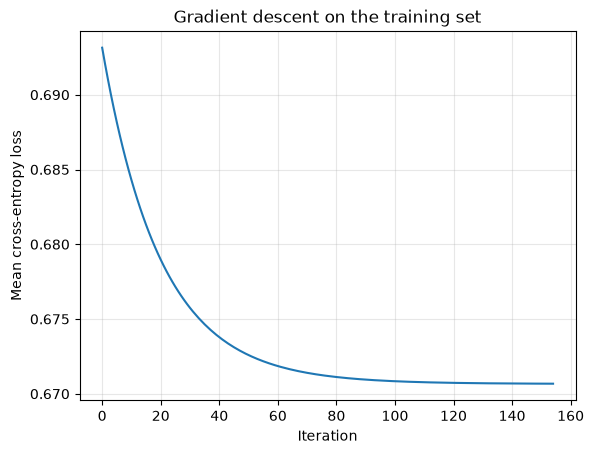

In [21]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Mean cross-entropy loss')
plt.title('Gradient descent on the training set')
plt.grid(alpha=0.3)
plt.show()

## Évaluation sur l'ensemble de test

Nous prédisons maintenant à la fois sur l'ensemble d'entraînement et sur l'ensemble de test. Les éditions antérieures de cette leçon évaluaient le modèle sur les données mêmes qui avaient servi à l'entraîner ; l'écart entre les deux nombres ci-dessous est exactement la raison pour laquelle cela surestime la compétence.

In [22]:
X_test_t = torch.from_numpy(x_test).float()
with torch.no_grad():
    proba_train = torch.sigmoid(X @ W + B).numpy()
    proba_test = torch.sigmoid(X_test_t @ W + B).numpy()

yhat_train = np.where(proba_train > 0.5, 1, 0)
yhat_test = np.where(proba_test > 0.5, 1, 0)

Calculons maintenant quelques métriques de classification à la main, sur l'ensemble de test. `N_test` est le nombre d'observations de test.

In [23]:
y_test = y_test_np
N_test = len(y_test)

In [24]:
# True positive
tp = np.sum((y_test == 1) & (yhat_test == 1))
print(tp / N_test)

0.006622516556291391


In [25]:
# False negative
fn = np.sum((y_test == 1) & (yhat_test == 0))
print(fn / N_test)

0.3973509933774834


In [26]:
# False positive
fp = np.sum((y_test == 0) & (yhat_test == 1))
print(fp / N_test)

0.004966887417218543


In [27]:
# True negative
tn = np.sum((y_test == 0) & (yhat_test == 0))
print(tn / N_test)

0.5910596026490066


In [28]:
# Accuracy (percentage of correct classifications)
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(accuracy)

0.597682119205298


In [29]:
# Recall (= sensitivity = percentage of positive values correctly classified)
recall = tp / (tp + fn)
print(recall)

0.01639344262295082


In [30]:
# Precision (= percentage of positive predictions that were correct)
precision = tp / (tp + fp)
print(precision)

0.5714285714285714


In [31]:
# F1
F1 = (2 * precision * recall) / (precision + recall)
print(F1)

0.03187250996015936


Comparez maintenant l'exactitude d'entraînement à l'exactitude de test, à côté du modèle de référence de la classe majoritaire.

In [32]:
train_accuracy = np.mean(yhat_train == y_train_np)
test_accuracy = np.mean(yhat_test == y_test)
print(f"Baseline (majority class): {baseline:.3f}")
print(f"Train accuracy:            {train_accuracy:.3f}")
print(f"Test accuracy:             {test_accuracy:.3f}")

Baseline (majority class): 0.597
Train accuracy:            0.606
Test accuracy:             0.598


La régression logistique bat à peine le modèle de référence de la classe majoritaire sur cette table, et le rappel sur la classe potable est faible. C'est un résultat honnête : ces 9 caractéristiques, combinées linéairement, portent peu de signal sur la cible. Un résultat quasi nul rapporté face à un modèle de référence est plus utile qu'un score d'entraînement gonflé. Si quelqu'un ne rapporte qu'une exactitude d'entraînement, demandez quel était le modèle de référence et ce que dit un ensemble de test tenu à l'écart.

## Les probabilités sont-elles honnêtes ?

Tout ce qui précède seuille la sortie de la sigmoïde à 0,5 et note les étiquettes obtenues. Mais le modèle produit une probabilité, et dans bien des applications c'est la probabilité elle-même que vous livrez. Un classifieur est **calibré** quand les probabilités qu'il annonce correspondent aux fréquences observées : parmi tous les échantillons de test où le modèle dit « 70 % de chances d'être potable », environ 70 % devraient être potables.

Deux outils le mesurent sur l'ensemble de test :

- Un **diagramme de fiabilité** (`sklearn.calibration.calibration_curve`) répartit les échantillons en intervalles de probabilité prédite et trace la fraction observée de positifs dans chaque intervalle contre la probabilité prédite moyenne. Un modèle calibré suit la diagonale.
- Le **score de Brier** est l'erreur quadratique moyenne de la probabilité, $\frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2$. Plus il est bas, mieux c'est. Contrairement à l'exactitude, qui ne voit que de quel côté de 0,5 tombe une prédiction, le score de Brier punit un 0,99 erroné bien plus durement qu'un 0,55 erroné.


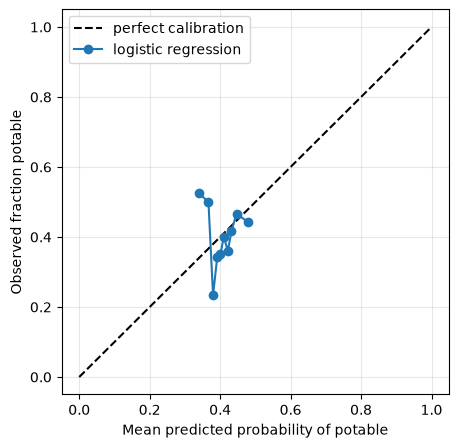

Logistic regression  Brier: 0.243  test accuracy: 0.598


In [33]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Brier score by hand: the mean squared error of the probability
brier_logistic = np.mean((proba_test - y_test) ** 2)

frac_pos, mean_pred = calibration_curve(
    y_test, proba_test, n_bins=10, strategy='quantile')

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
plt.plot(mean_pred, frac_pos, 'o-', label='logistic regression')
plt.xlabel('Mean predicted probability of potable')
plt.ylabel('Observed fraction potable')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Logistic regression  Brier: {brier_logistic:.3f}  "
      f"test accuracy: {test_accuracy:.3f}")


Les probabilités du modèle ne couvrent qu'environ 0,27 à 0,57 : il ne revendique jamais de certitude sur aucun échantillon, ce qui est cohérent avec le faible signal de ces caractéristiques. La courbe oscille autour de la diagonale, la plupart des intervalles du milieu se tenant en dessous — là où le modèle dit 40 % potable, la fréquence observée est plus proche de 30–40 %, une légère surconfiance en faveur de la classe potable. Chaque intervalle de quantiles contient environ 60 échantillons de test, chaque fraction observée porte donc un bruit d'échantillonnage d'environ ±0,06, et seuls les écarts plus grands que cela méritent interprétation. Verdict : à peu près honnête, faiblement informatif. Les probabilités sont utilisables, mais elles ne font pour l'essentiel que redire le taux de base.


### Un concurrent trop sûr de lui, et comment le réparer

Une méthode `predict_proba` ne garantit en rien que les nombres qui en sortent méritent le nom de probabilités. Prenez une petite forêt aléatoire : 10 arbres profonds, dont chacun mémorise presque l'ensemble d'entraînement. Sa « probabilité » d'être potable est la fraction des arbres qui votent potable, et avec 10 arbres surappris ces fractions atterrissent facilement sur des valeurs extrêmes comme 0,9 ou 1,0.


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=10, random_state=0)
rf.fit(x_train, y_train_np)
proba_rf = rf.predict_proba(x_test)[:, 1]

brier_rf = brier_score_loss(y_test, proba_rf)
acc_rf = np.mean((proba_rf > 0.5) == y_test)
print(f"Random forest  train accuracy: {rf.score(x_train, y_train_np):.3f}")
print(f"Random forest  test accuracy:  {acc_rf:.3f}   Brier: {brier_rf:.3f}")


Random forest  train accuracy: 0.974
Random forest  test accuracy:  0.619   Brier: 0.239


La forêt mémorise l'ensemble d'entraînement et bat quand même le modèle logistique en exactitude de test. Vérifiez maintenant si l'on peut faire confiance à ses probabilités, et réparez-les sinon. L'enjeu est concret : quand un modèle annonce « 80 % de chances » à un service de prévention des risques, environ 80 % de ces cas doivent se réaliser, sans quoi le nombre n'est pas une prévision sur laquelle on peut agir. La réparation ré-étiquette les scores du modèle à partir des fréquences observées : mettez des échantillons de côté, enregistrez à quelle fréquence les échantillons notés près de 0,9 se révèlent effectivement potables, et corrigez chaque score vers cette fréquence observée. Seules les corrections préservant l'ordre sont permises — si la forêt a noté l'échantillon A au-dessus de l'échantillon B, la probabilité corrigée de A reste au niveau ou au-dessus de celle de B — l'ordre des échantillons survit donc ; seuls les nombres qui lui sont attachés changent. `CalibratedClassifierCV` fournit les échantillons mis de côté en réajustant la forêt sur des plis de validation croisée (les découpages tournants de la leçon 3.8), et le nom que scikit-learn donne à l'ajustement préservant l'ordre est la régression isotonique (`method='isotonic'`).


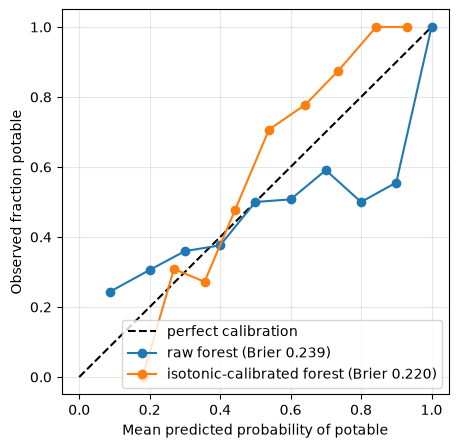

Raw forest         Brier: 0.239   accuracy: 0.619
Calibrated forest  Brier: 0.220   accuracy: 0.664


In [35]:
from sklearn.calibration import CalibratedClassifierCV

cal_rf = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=10, random_state=0),
    method='isotonic', cv=5)
cal_rf.fit(x_train, y_train_np)
proba_cal = cal_rf.predict_proba(x_test)[:, 1]

brier_cal = brier_score_loss(y_test, proba_cal)
acc_cal = np.mean((proba_cal > 0.5) == y_test)

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
for proba, brier, label in [
        (proba_rf, brier_rf, 'raw forest'),
        (proba_cal, brier_cal, 'isotonic-calibrated forest')]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    plt.plot(mean_pred, frac_pos, 'o-', label=f'{label} (Brier {brier:.3f})')
plt.xlabel('Mean predicted probability of potable')
plt.ylabel('Observed fraction potable')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Raw forest         Brier: {brier_rf:.3f}   accuracy: {acc_rf:.3f}")
print(f"Calibrated forest  Brier: {brier_cal:.3f}   accuracy: {acc_cal:.3f}")


La courbe de la forêt brute tombe loin sous la diagonale à droite : là où elle revendique 80 % ou 90 % de chances d'être potable, la fréquence observée est proche de 50 %. Elle ment avec assurance exactement dans la plage où un utilisateur agirait, et son exactitude de test n'en laisse rien paraître. La calibration isotonique abaisse le score de Brier et rapproche la courbe de la diagonale, sans l'y amener tout à fait : la carte de calibration est estimée sur environ 1400 lignes d'entraînement et porte son propre bruit d'échantillonnage. L'exactitude s'améliore aussi un peu, en partie parce que `CalibratedClassifierCV` moyenne les cinq forêts qu'il ajuste sur les plis — un petit bonus d'ensemble, pas l'objet de l'exercice.

Dans les contextes de risque, la probabilité est le livrable, pas l'étiquette. Un ingénieur géotechnicien rapporte une probabilité de liquéfaction qui entre dans une vérification réglementaire de construction ; un gestionnaire de l'eau agit sur une probabilité d'efflorescence algale nuisible ; une carte de zones inondables encode des probabilités de dépassement de crue. La personne qui fixe le seuil de décision — quelle probabilité justifie le coût d'agir — n'est généralement pas celle qui a entraîné le modèle, et elle prendra le nombre pour argent comptant. Un 90 % mal calibré qui signifie en réalité 55 % déplace silencieusement votre erreur de modélisation dans la décision de quelqu'un d'autre. Chaque fois que les probabilités d'un modèle alimentent un seuil qui ne vous appartient pas, rapportez un diagramme de fiabilité et un score de Brier à côté de l'exactitude. Le désaccord au sein d'un ensemble de modèles donne une vue complémentaire de l'incertitude dans la leçon 3.9, et le même contrôle de fiabilité est appliqué aux ensembles profonds dans la leçon 4.5.


## Annexe

La régression logistique est un bel exemple pour commencer à apprendre la différenciation automatique et PyTorch. Cependant, si vous voulez réellement utiliser la régression logistique sur votre propre jeu de données, il est bien plus simple d'utiliser la fonction qui existe déjà dans scikit-learn. Nous suivons le même protocole : ajuster sur l'ensemble d'entraînement, rapporter sur l'ensemble de test.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support

In [37]:
model = LogisticRegression(random_state=0).fit(x_train, y_train_np)

In [38]:
model.coef_

array([[ 0.04513734, -0.02944814,  0.12027801,  0.05730839, -0.04010493,
        -0.07808411,  0.02579578,  0.00593486,  0.02137578]])

In [39]:
model.intercept_

array([-0.39579648])

### Lire les coefficients

Les caractéristiques ont été standardisées, chaque coefficient est donc la variation du **logarithme des cotes** (*log-odds*) de potabilité pour une augmentation d'un écart-type de la caractéristique concernée, les autres restant fixes. En passant à l'exponentielle, on obtient un **rapport de cotes** (*odds ratio*) : un coefficient $w_j$ multiplie les cotes de potabilité par $e^{w_j}$ par écart-type de la caractéristique $j$. La cellule ci-dessous lit ainsi le plus grand coefficient.

Deux mises en garde. D'abord, le signe d'un coefficient décrit le modèle ajusté, pas la chimie de l'eau : avec des caractéristiques corrélées et un signal aussi faible, l'ajustement peut attribuer un signe chimiquement invraisemblable à une caractéristique pendant qu'une caractéristique corrélée absorbe l'effet opposé — la même mise en garde que pour l'importance des caractéristiques dans la leçon [3.7](3.7_randomForest_regression.ipynb). Ensuite, la ``LogisticRegression`` de sklearn applique par défaut une régularisation L2 (``C=1.0``), ses coefficients sont donc rétrécis vers zéro et diffèrent de l'ajustement sans pénalité obtenu ci-dessus par descente de gradient — à peine ici, parce qu'avec environ 2000 échantillons d'entraînement la pénalité par défaut est douce, mais le tableau ci-dessous montre les deux vecteurs de coefficients côte à côte, pour que vous vérifiiez au lieu de supposer.

In [40]:
feature_names = data.drop(columns=['Potability']).columns
coefs = pd.DataFrame(
    {"gradient descent (no penalty)": W.detach().numpy(),
     "sklearn (L2, C=1.0)": model.coef_[0]},
    index=feature_names)
print(coefs.round(3))

top = coefs["sklearn (L2, C=1.0)"].abs().idxmax()
w_top = coefs.loc[top, "sklearn (L2, C=1.0)"]
print(f"\nOne standard deviation of {top} multiplies the odds of potability "
      f"by exp({w_top:.3f}) = {np.exp(w_top):.3f}")

                 gradient descent (no penalty)  sklearn (L2, C=1.0)
ph                                       0.043                0.045
Hardness                                -0.028               -0.029
Solids                                   0.117                0.120
Chloramines                              0.055                0.057
Sulfate                                 -0.040               -0.040
Conductivity                            -0.076               -0.078
Organic_carbon                           0.024                0.026
Trihalomethanes                          0.006                0.006
Turbidity                                0.021                0.021

One standard deviation of Solids multiplies the odds of potability by exp(0.120) = 1.128


In [41]:
yhat_sk = model.predict(x_test)

In [42]:
metrics = precision_recall_fscore_support(y_test, yhat_sk, average='binary')
(precision_sk, recall_sk, F1_sk) = (metrics[0], metrics[1], metrics[2])
print(precision_sk, recall_sk, F1_sk)

0.5714285714285714 0.01639344262295082 0.03187250996015936


In [43]:
print(f"sklearn train accuracy: {model.score(x_train, y_train_np):.3f}")
print(f"sklearn test accuracy:  {model.score(x_test, y_test):.3f}")

sklearn train accuracy: 0.606
sklearn test accuracy:  0.598
